In [ ]:
!pip install pandas pyarrow
!pip install censusdis
!pip install pandas geopandas shapely censusdis pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.9/435.9 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: certifi
    Found existing installation: certifi 2025.11.12
    Uninstalling certifi-2025.11.12:
      Successfully uninstalled certifi-2025.11.12
  Attempting uninstall: pyogrio
    Found existing installation: pyogrio 0.11.1
    Uninstalling pyogrio-0.11.1:
      Successfully uninstalled pyogrio-0.11.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.1
    Uninstalling geopandas-1.

In [ ]:
# -----------------------------------------
# Analisis de Datos
# Francheska Lebron
# Luis Fontan
# -----------------------------------------

In [ ]:
import pandas as pd
import censusdis.data as ced

# -----------------------------------------
#Lectura data (archivo .parquet)
# -----------------------------------------

file_path = 'ccom6994_pv_dataset.parquet'
df = pd.read_parquet(file_path)
df.head()

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date
0,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-177.92735830000007 -29.246487...,505.911148,-29.246515,-177.927191,615778481436884991,19077,NaN,NaN,None
1,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,"POLYGON ((-152.7975221 -22.64438619999985, -15...",722.751608,-22.644508,-152.797387,615667837104553983,34745,NaN,NaN,None
2,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-70.9484344 -53.20046109999999...,442.152434,-53.200533,-70.948352,616420125630791679,19196,NaN,NaN,None
3,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-69.54785590000002 -52.4561568...,45.555486,-52.456164,-69.547781,616142442372005887,19206,NaN,NaN,None
4,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-62.988899400000015 -40.80502199999996),0.000000,-40.805022,-62.988899,615920622922366975,4858,NaN,NaN,None


In [ ]:
import geopandas as gpd

# -----------------------------------------
# Convertir datos de placas solares (archivo .parquet) a GeoDataFrame (data mundial)
# -----------------------------------------

gdf_solar = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["geometry"]) if df["geometry"].dtype == "object" else df["geometry"])

# -----------------------------------------
# Asegurar CRS (suponiendo WGS84)
# -----------------------------------------
gdf_solar = gdf_solar.set_crs(epsg=4326)

In [ ]:
import censusdis.data as ced
import pandas as pd

# -----------------------------------------
# Definir dataset ACS y variables
# -----------------------------------------
DATASET = "acs/acs5"
PROFILE = "acs/acs5/profile"
YEAR = 2022

# -----------------------------------------
# Variables ACS detalladas
# -----------------------------------------

vars_detailed = [
    "NAME",
    "B01003_001E",   # poblacion total
    "B19013_001E",   # ingreso mediano
    "B17001_002E",   # bajo pobreza
    "B25077_001E",   # valor mediano vivienda
]
# -----------------------------------------
# Variables ACS Profile
# -----------------------------------------

vars_profile = [
    "DP03_0009PE",   # % desempleo
    "DP02_0068PE",   # % bachillerato o más
    "DP05_0071PE",   # % hispano
]



In [ ]:
# -----------------------------------------
# Descargar data (solo California)
# -----------------------------------------
gdf_prof = ced.download(
    PROFILE,
    YEAR,
    vars_profile,
    state="06",
    county="*",
    tract="*",
    with_geometry=False
)

gdf_det = ced.download(
    DATASET,
    YEAR,
    vars_detailed,
    state="06",      # California
    county="*",
    tract="*",
    with_geometry=True
)

# -----------------------------------------
# Renombrar geometría
# -----------------------------------------

gdf_det = gdf_det.rename(columns={"geometry": "geometry_census"})
gdf_det = gdf_det.set_geometry("geometry_census")




In [ ]:

# -----------------------------------------
# Unir ambas tablas
# -----------------------------------------
gdf = gdf_det.merge(
    gdf_prof,
    on=["STATE", "COUNTY", "TRACT"],
    how="left"
)
9
# -----------------------------------------
# Renombrar columnas
# -----------------------------------------
gdf = gdf.rename(columns={
    "B01003_001E": "poblacion_total",
    "B19013_001E": "ingreso_medio_hogar",
    "B17001_002E": "poblacion_bajo_pobreza",
    "B25077_001E": "valor_medio_vivienda",
    "DP03_0009PE": "porc_desempleo",
    "DP02_0068PE": "porc_educ_bachillerato",
    "DP05_0071PE": "porc_hispano"
})

# -----------------------------------------
# Asegurar CRS
# -----------------------------------------
gdf = gdf.set_crs(epsg=4269).to_crs(epsg=4326)



In [ ]:
from shapely.geometry import Point

# -----------------------------------------

#hacer Join Geoespacial  de Datos de Placas Solares y del Censo
# -----------------------------------------

gdf_points = gdf_solar.copy()
gdf_points["geometry"] = [
    Point(lon, lat)
    for lon, lat in zip(gdf_points["centroid_lon"], gdf_points["centroid_lat"])
]
gdf_points = gdf_points.set_crs(epsg=4326)

gdf_california = gpd.sjoin(
    gdf_points,
    gdf,
    how="left",
    predicate="within"
)


gdf_california

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,...,COUNTY,TRACT,NAME,poblacion_total,ingreso_medio_hogar,poblacion_bajo_pobreza,valor_medio_vivienda,porc_desempleo,porc_educ_bachillerato,porc_hispano
0,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-177.92719 -29.24651),505.911148,-29.246515,-177.927191,615778481436884991,19077,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-152.79739 -22.64451),722.751608,-22.644508,-152.797387,615667837104553983,34745,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-70.94835 -53.20053),442.152434,-53.200533,-70.948352,616420125630791679,19196,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-69.54778 -52.45616),45.555486,-52.456164,-69.547781,616142442372005887,19206,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-62.9889 -40.80502),0.000000,-40.805022,-62.988899,615920622922366975,4858,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443742,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (143.89265 -39.93811),732.052270,-39.938106,143.892652,616299517211312127,19221,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443743,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POINT (146.55166 -38.17957),20987.479133,-38.179572,146.551657,615838840094982143,465.0,12968.531637,1.119601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443744,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (148.06426 -42.58429),77.507376,-42.584288,148.064258,615854879845384191,35203,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443745,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (147.50307 -42.86353),25.670090,-42.863530,147.503067,615854925817053183,19219,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
gdf_california_full = gdf_california[gdf_california["STATE"] == "06"].copy()


In [ ]:
len(gdf_california_full.geometry)

25287

In [ ]:
# -----------------------------------------
#Contar cantidad de placas solares por County
# -----------------------------------------

conteo = (
    gdf_california_full
    .groupby(["STATE", "COUNTY","TRACT"], as_index=False)
    .size()
    .rename(columns={"size": "n_plantas"})
)

# -----------------------------------------
# Unir conteo al geodataframe
# -----------------------------------------

gdf_california_full = gdf.merge(
    conteo,
    on=["STATE", "COUNTY", "TRACT"],
    how="left"
).fillna({"n_plantas": 0})


In [ ]:
# -----------------------------------------
# Proyectar counties a CRS adecuado para área en California
# -----------------------------------------

gdf_california_full = gdf_california_full.to_crs(epsg=3310)

# -----------------------------------------
# Calcular área del tract en km²
# -----------------------------------------

gdf_california_full["area_km2"] = gdf_california_full["geometry_census"].area / 1_000_000

# -----------------------------------------
# Calcular densidad de plantas solares
# -----------------------------------------

gdf_california_full["densidad_solar"] = (
    gdf_california_full["n_plantas"] / gdf_california_full["area_km2"]
)

# -----------------------------------------
# Variable binaria: presencia o ausencia de plantas solares
# -----------------------------------------

gdf_california_full["tiene_solar"] = (gdf_california_full["n_plantas"] > 0).astype(int)


In [ ]:
gdf_california_full.n_plantas


,n_plantas
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
9124,1.0
9125,2.0
9126,0.0
9127,0.0


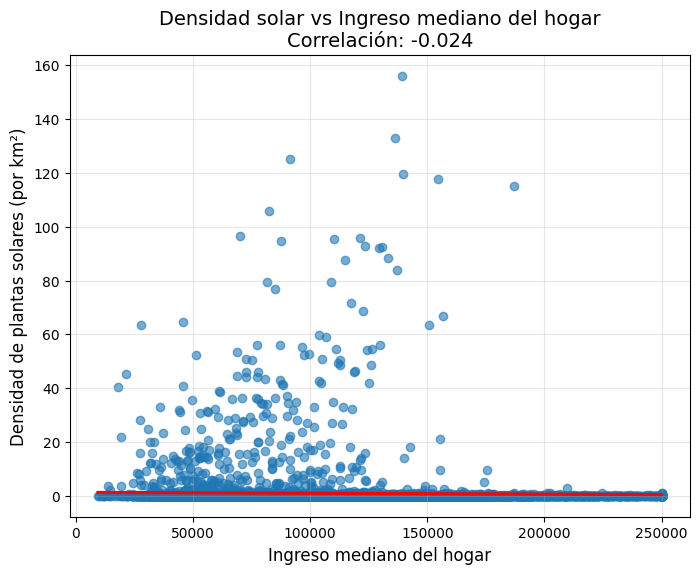

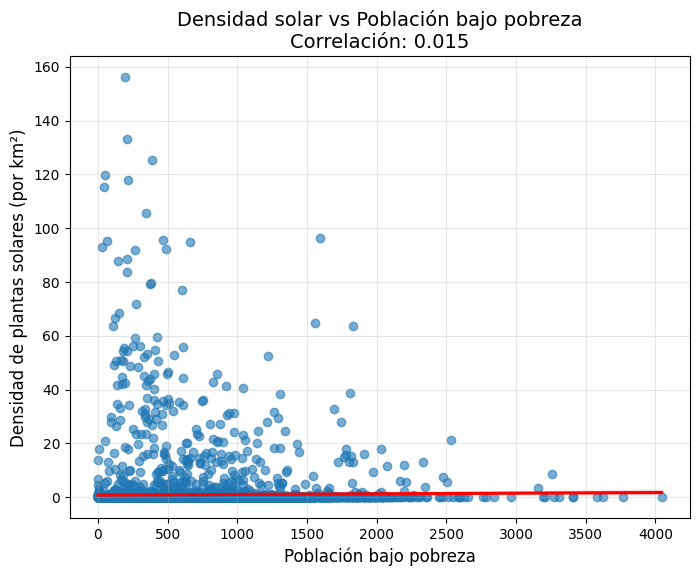

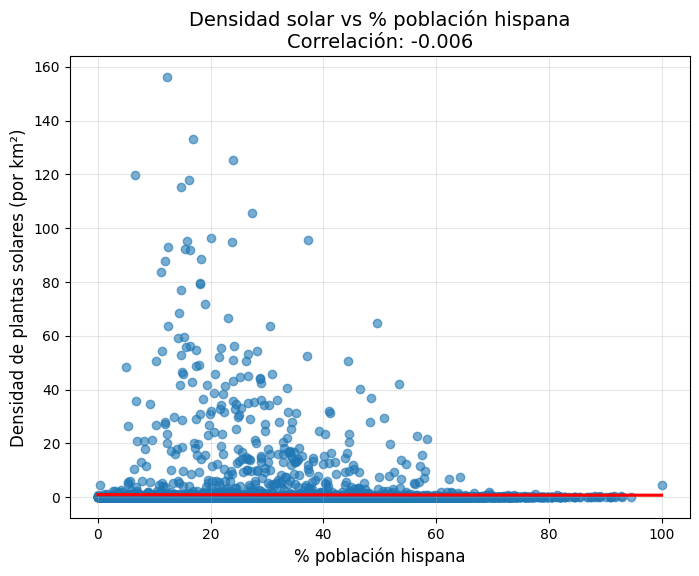

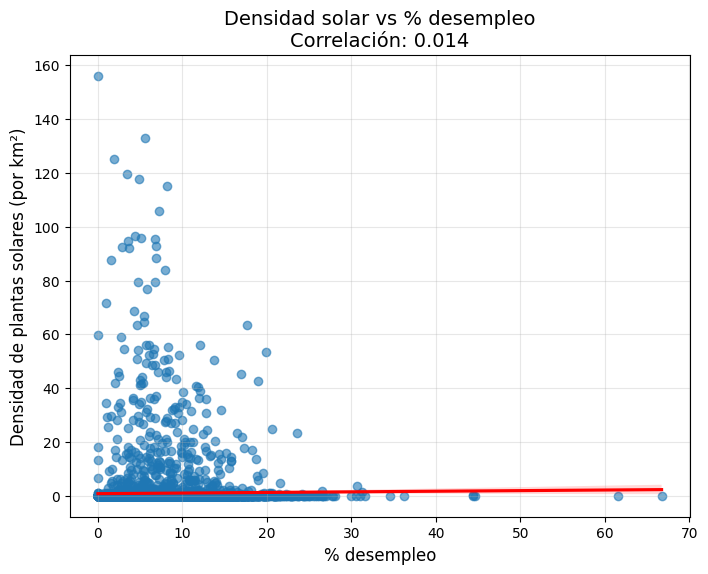

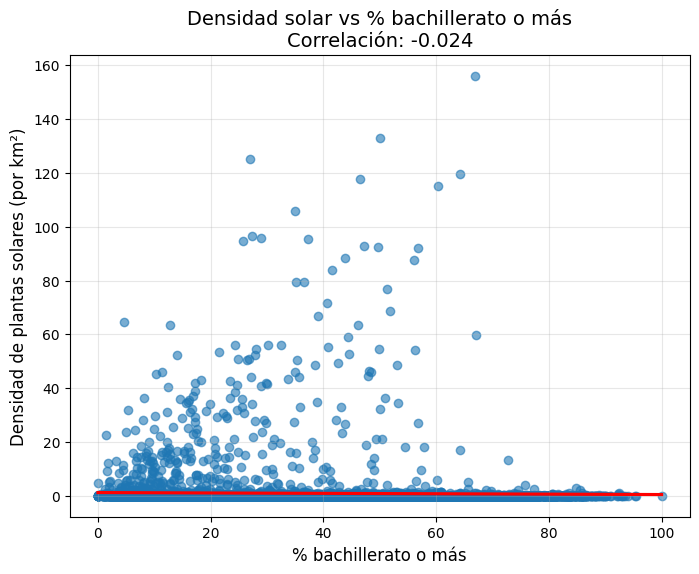

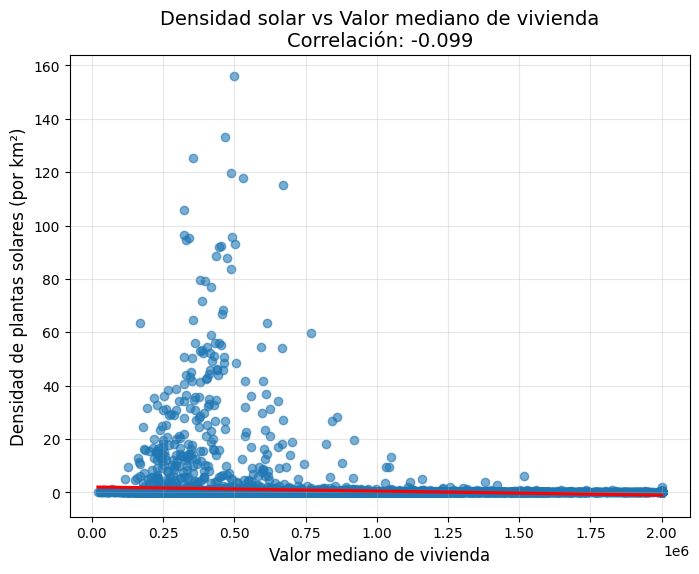

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# -----------------------------------------
# Creación de Scatterplot y correlación
# -----------------------------------------

vars_to_plot = [
    ("ingreso_medio_hogar", "Ingreso mediano del hogar"),
    ("poblacion_bajo_pobreza", "Población bajo pobreza"),
    ("porc_hispano", "% población hispana"),
    ("porc_desempleo", "% desempleo"),
    ("porc_educ_bachillerato", "% bachillerato o más"),
    ("valor_medio_vivienda", "Valor mediano de vivienda"),
]



for var, label in vars_to_plot:
    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=gdf_california_full,
        x=var,
        y="densidad_solar",
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )

    # -----------------------------------------
    # Correlación Pearson
    corr = gdf_california_full[[var, "densidad_solar"]].corr().iloc[0, 1]

    plt.title(f"Densidad solar vs {label}\nCorrelación: {corr:.3f}", fontsize=14)
    plt.xlabel(label, fontsize=12)
    plt.ylabel("Densidad de plantas solares (por km²)", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()


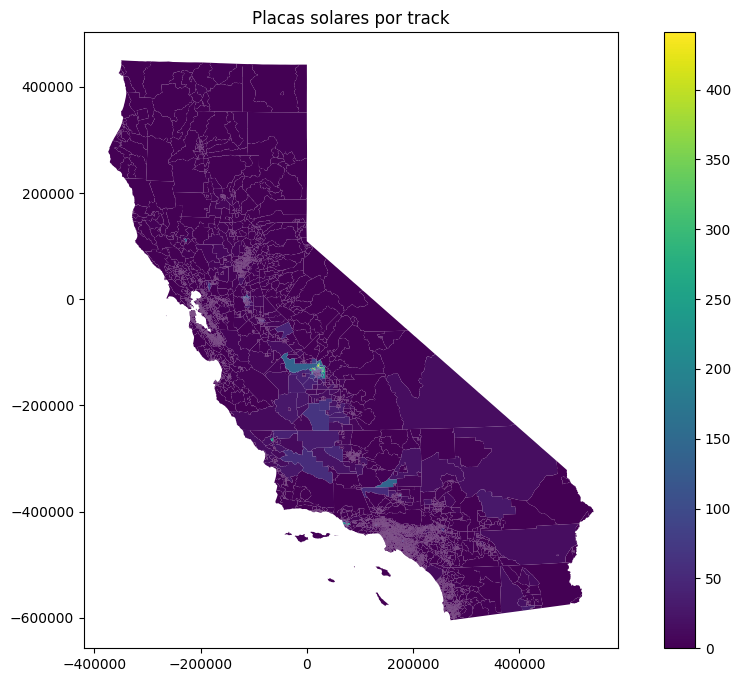

In [ ]:
# -----------------------------------------
#Mapa de Tract de California y distribución de cantidad de infraetsructura solar
# -----------------------------------------

gdf_california_full.plot(
    column="n_plantas",
    figsize=(12,8),
    legend=True,
    cmap="viridis"
)
plt.title("Placas solares por tract")
plt.show()

In [ ]:
# -----------------------------------------
#Identificando que tract tiene mayor cantidad de placas solares
# -----------------------------------------
fila_max = gdf_california_full.loc[gdf_california_full["n_plantas"].idxmax()]



,918
STATE,06
COUNTY,019
TRACT,005529
NAME,Census Tract 55.29; Fresno County; California
poblacion_total,6185
ingreso_medio_hogar,139250.0
poblacion_bajo_pobreza,194
valor_medio_vivienda,498600.0
geometry_census,POLYGON ((20830.503294543807 -124579.894617339...
porc_desempleo,0.0


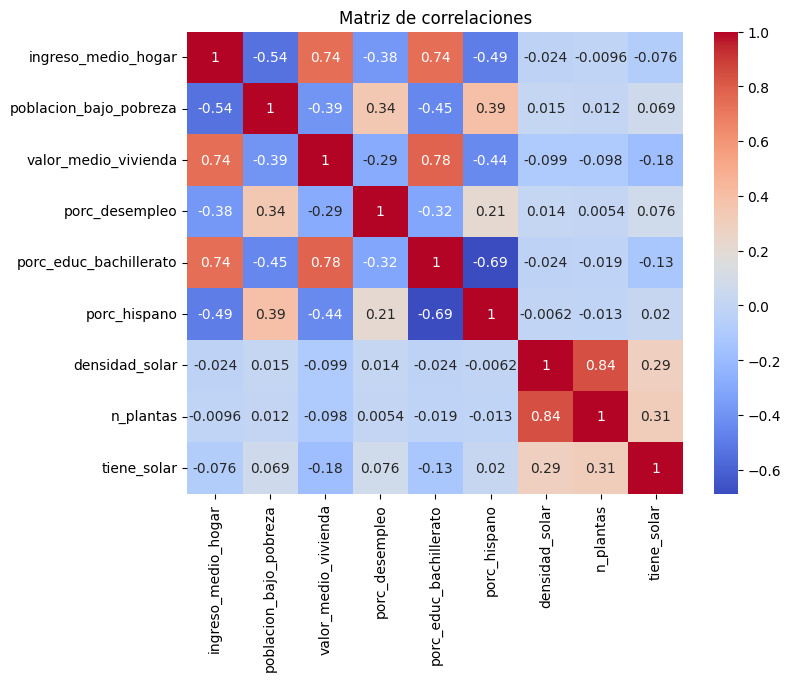

In [ ]:
# -----------------------------------------
#matriz de correlación entre todas las variables
# -----------------------------------------

plt.figure(figsize=(8,6))
sns.heatmap(
    gdf_california_full[["ingreso_medio_hogar","poblacion_bajo_pobreza",
               "valor_medio_vivienda","porc_desempleo","porc_educ_bachillerato",
                        "porc_hispano", "densidad_solar","n_plantas","tiene_solar" ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlaciones")
plt.show()


In [ ]:
gdf_california_full.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9129 entries, 0 to 9128
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   STATE                   9129 non-null   object  
 1   COUNTY                  9129 non-null   object  
 2   TRACT                   9129 non-null   object  
 3   NAME                    9129 non-null   object  
 4   poblacion_total         9129 non-null   int64   
 5   ingreso_medio_hogar     8988 non-null   float64 
 6   poblacion_bajo_pobreza  9129 non-null   int64   
 7   valor_medio_vivienda    8766 non-null   float64 
 8   geometry_census         9109 non-null   geometry
 9   porc_desempleo          9056 non-null   float64 
 10  porc_educ_bachillerato  9076 non-null   float64 
 11  porc_hispano            9080 non-null   float64 
 12  n_plantas               9129 non-null   float64 
 13  area_km2                9109 non-null   float64 
 14  densidad_solar  

In [ ]:
# -----------------------------------------
#Cantidad de datos missing
# -----------------------------------------

gdf_california_full.isna().sum()


,0
STATE,0
COUNTY,0
TRACT,0
NAME,0
poblacion_total,0
ingreso_medio_hogar,141
poblacion_bajo_pobreza,0
valor_medio_vivienda,363
geometry_census,20
porc_desempleo,73


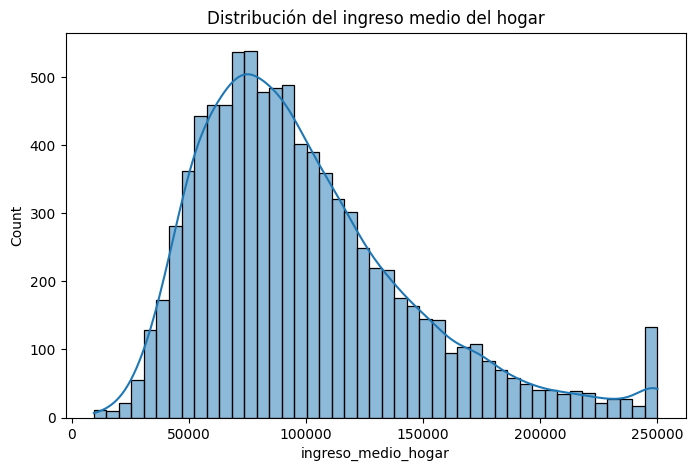

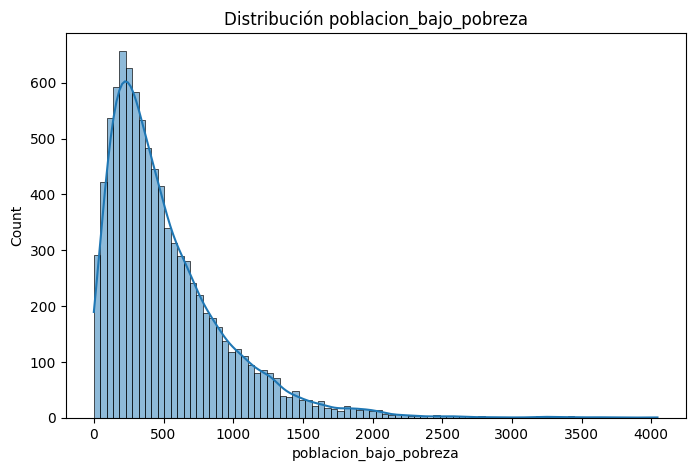

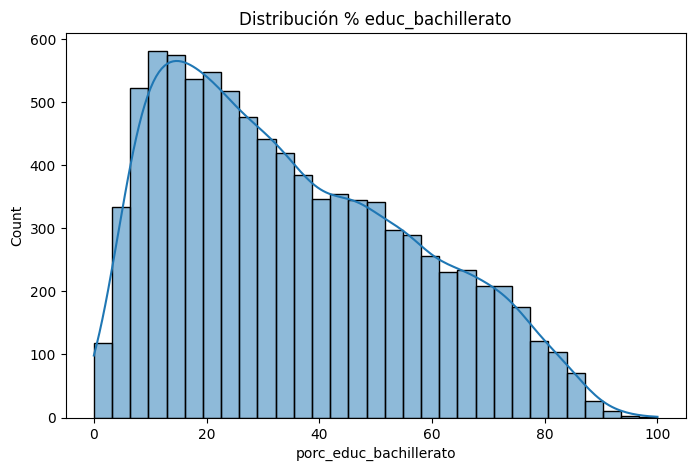

In [ ]:
# -----------------------------------------
#Observando si las variables se comportan normalmente
# -----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(gdf_california_full["ingreso_medio_hogar"], kde=True)
plt.title("Distribución del ingreso medio del hogar")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(gdf_california_full["poblacion_bajo_pobreza"], kde=True)
plt.title("Distribución poblacion_bajo_pobreza")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(gdf_california_full["porc_educ_bachillerato"], kde=True)
plt.title("Distribución % educ_bachillerato")
plt.show()


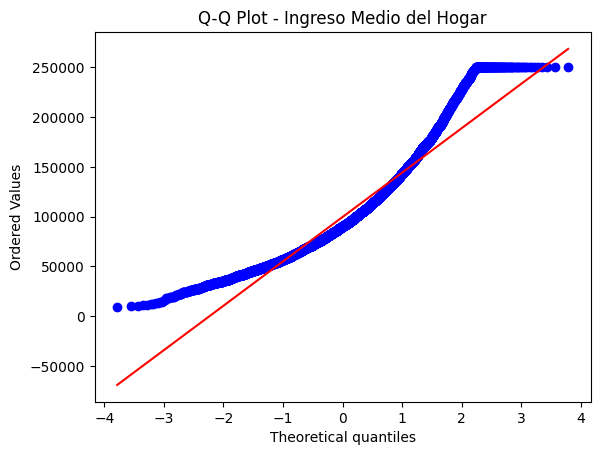

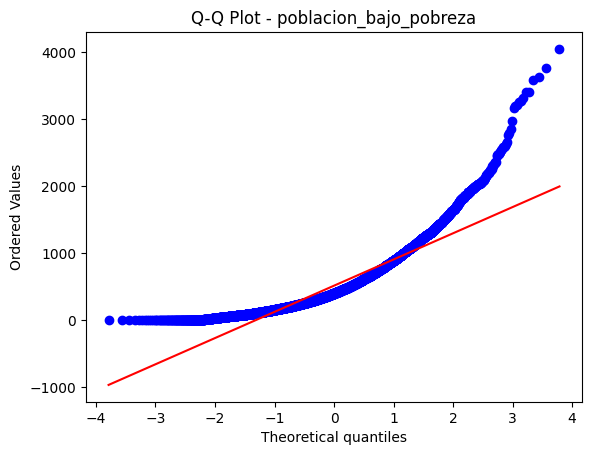

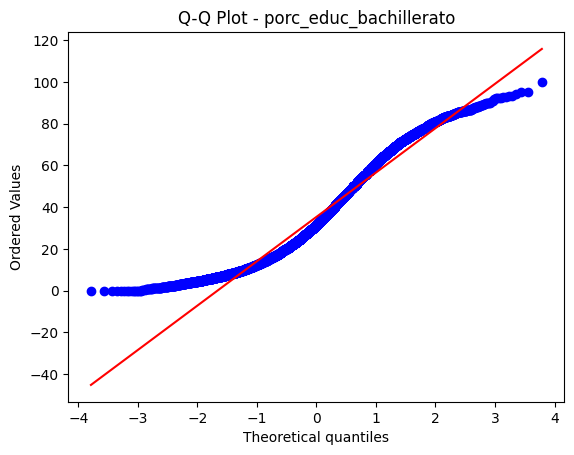

In [ ]:
# -----------------------------------------
#Prueba para comprobar que no se comportan normalemnte las variables
# -----------------------------------------

import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(gdf_california_full["ingreso_medio_hogar"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot - Ingreso Medio del Hogar")
plt.show()

stats.probplot(gdf_california_full["poblacion_bajo_pobreza"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot - poblacion_bajo_pobreza")
plt.show()

stats.probplot(gdf_california_full["porc_educ_bachillerato"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot - porc_educ_bachillerato")
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu
# -----------------------------------------
#¿Los tracts que tienen plantas solares son socioeconómicamente distintos a los que no tienen?
# -----------------------------------------



# Lista de variables que quieres evaluar
variables = [
    "ingreso_medio_hogar",
    "poblacion_bajo_pobreza",
    "valor_medio_vivienda",
    "porc_educ_bachillerato",
    "porc_hispano",
    "porc_desempleo"
]

# Eliminar NAs solo una vez en todas las variables
df = gdf_california_full.dropna(subset=variables)

resultados = []

for var in variables:

    group_yes = df[df["tiene_solar"] == 1][var]
    group_no  = df[df["tiene_solar"] == 0][var]

    stat, p = mannwhitneyu(group_yes, group_no)

    resultados.append({
        "variable": var,
        "U_statistic": stat,
        "p_value": p
    })

# Convertir a DataFrame
tabla_resultados = pd.DataFrame(resultados)
tabla_resultados



,variable,U_statistic,p_value
0,ingreso_medio_hogar,4974878.5,1.618637e-12
1,poblacion_bajo_pobreza,6207584.5,5.100193e-11
2,valor_medio_vivienda,3837266.0,6.420921e-86
3,porc_educ_bachillerato,4518767.0,9.597477e-34
4,porc_hispano,6004607.5,1.536689e-05
5,porc_desempleo,6198305.5,1.008661e-10


In [55]:
vars_interes = [
    "ingreso_medio_hogar",
    "poblacion_bajo_pobreza",
    "valor_medio_vivienda",
    "porc_educ_bachillerato",
    "porc_hispano",
    "porc_desempleo"
]

medianas = (
    gdf_california_full
    .groupby("tiene_solar")[vars_interes]
    .mean()
    .rename(index={0: "sin_solar", 1: "con_solar"})
)

medianas


,ingreso_medio_hogar,poblacion_bajo_pobreza,valor_medio_vivienda,porc_educ_bachillerato,porc_hispano,porc_desempleo
tiene_solar,,,,,,
sin_solar,102589.560496,497.124338,779649.942710,36.858656,24.783398,6.351826
con_solar,92850.118211,588.258786,576817.969329,29.369776,25.736805,7.139042


In [54]:
import statsmodels.formula.api as smf
#---------------------------------
# Modelo Logistico
#------------------------------

model = smf.logit(
    formula="tiene_solar ~ ingreso_medio_hogar + poblacion_bajo_pobreza + valor_medio_vivienda + porc_educ_bachillerato + porc_hispano + porc_desempleo",
    data=gdf_california_full
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.442012
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            tiene_solar   No. Observations:                 8739
Model:                          Logit   Df Residuals:                     8732
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                 0.05955
Time:                        02:15:17   Log-Likelihood:                -3862.7
converged:                       True   LL-Null:                       -4107.3
Covariance Type:            nonrobust   LLR p-value:                1.822e-102
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.9383      0.152     -6.183      0.000      -1.236      